# Not full Kalman filters but random stuff 

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [63]:
def noise(cov: np.ndarray):
    return np.random.multivariate_normal(
        mean = np.zeros(cov.shape[0]),
        cov=cov
    )

def noise_vec(std_dev: float, n: int):
    return np.random.normal(0, std_dev, size=n)

def get_freq(y, N, dt):
    y_f = fft(y)
    y_f = 2.0/N * np.abs(y_f[0:N//2])
    x_f = fftfreq(N, dt)[:N//2]

    return x_f, y_f

## Low pass
https://en.wikipedia.org/wiki/Low-pass_filter#Simple_infinite_impulse_response_filter

In [41]:
dt = 0.01
nsteps = 1000
ts = np.arange(nsteps + 1)*dt # [0:tf] inclusive so N+1 points

R = 2 # noise

ys = np.sin(ts)*15 + noise_vec(R, nsteps + 1)

In [42]:
class LPF:
    def __init__(self, alpha: float):
        self.alpha = alpha
        self.y = 0
    
    def run(self, x):
        self.y = self.alpha*x + (1-self.alpha)*self.y

        return self.y

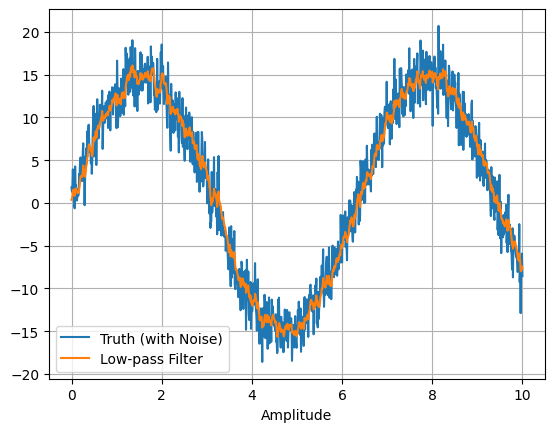

In [43]:
# Change this for different filter levels 
# Higher alpha --> weight current measurement more
# Lower alpha --> More filter / weights previous measurements more
alpha = 0.2

low_pass = LPF(alpha)
ys_lp = [low_pass.run(x) for x in ys]


plt.plot(ts, ys, label="Truth (with Noise)")
plt.plot(ts, ys_lp, label="Low-pass Filter")
plt.xlabel("Time [s]")
plt.xlabel("Amplitude")
plt.legend()
plt.grid()
plt.show()
# Note how there's more lag the smaller alpha gets

## High pass
https://en.wikipedia.org/wiki/High-pass_filter#Algorithmic_implementation

In [57]:
# Change this for different filter levels 
# Higher alpha --> weight current measurement more
# Lower alpha --> More filter / weights previous measurements more
alpha = 0.5

R = 20 # noise

dt = 0.01
nsteps = 1000

ts = np.arange(nsteps + 1)*dt # [0:tf] inclusive so N+1 points

# ys = np.sin(ts)*15
# ys = [y + noise(R) for y in ys]

w = 15
ys = np.sin(ts * 2*np.pi*w)*30 + noise_vec(R, nsteps + 1)

In [58]:
class HPF:
    def __init__(self, alpha: float):
        self.alpha = alpha
        self.x_prev = 0
        self.y = 0
    
    def run(self, x):
        self.y = self.alpha*self.y + self.alpha*(x - self.x_prev)

        return self.y

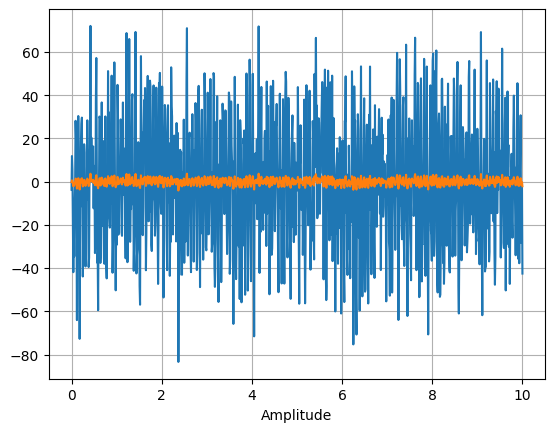

In [59]:
# Change this for different filter levels 
# Higher alpha --> weight current measurement more
# Lower alpha --> More filter / weights previous measurements more
alpha = 0.05

R = 2*np.eye(1) # noise

high_pass = HPF(alpha)
ys_hp = [high_pass.run(x) for x in ys]

plt.plot(ts, ys, label="Truth (with Noise)")
plt.plot(ts, ys_hp, label="High-pass Filter")
plt.xlabel("Time [s]")
plt.xlabel("Amplitude")
plt.grid()
plt.show()

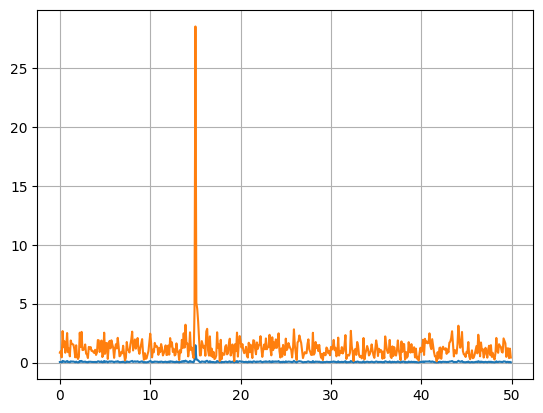

In [72]:
# fft
x_f, hp_f = get_freq(ys_hp, nsteps, dt)
_, freq_true = get_freq(ys, nsteps, dt)
plt.plot(x_f, hp_f)
plt.plot(x_f, freq_true)
plt.grid()

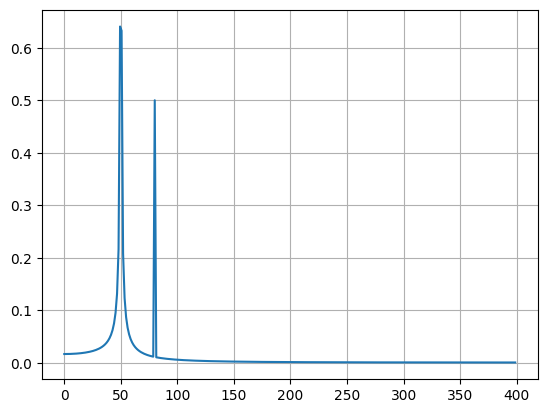

In [49]:

# Number of sample points
N = 600
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N, endpoint=False)
y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
yf = fft(y)
xf = fftfreq(N, T)[:N//2]
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.grid()
plt.show()